Localizing object occurrence:   0%|          | 0/43.026316666666666 [00:00<?, ?chunks/s]

Localizing object occurrence: 44chunks [03:08,  4.29s/chunks]                                    


Associated object: bowl
Total frames in segment: 8091
Segment start time (s): 299.97
Segment end time (s): 569.94
Segment duration (s): 269.97


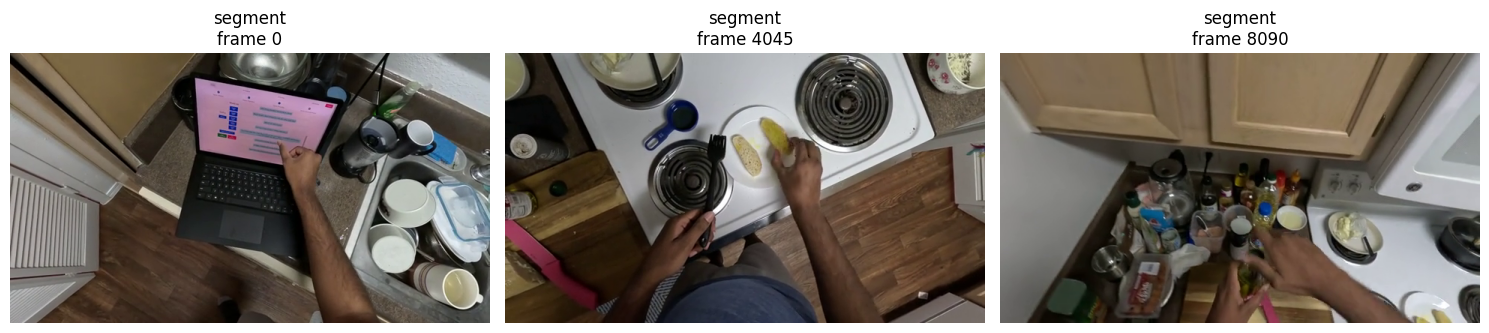

In [7]:
import matplotlib.pyplot as plt
import cv2
from episodic_memory.process import prepare_data_for_episodic_memory
import json
from pathlib import Path

def show_frames(frames, indices, title_prefix="segment"):
    plt.figure(figsize=(15, 4))
    for i, idx in enumerate(indices, 1):
        idx = max(0, min(idx, len(frames)-1))
        img = cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB)
        ax = plt.subplot(1, len(indices), i)
        ax.imshow(img)
        ax.set_title(f"{title_prefix}\nframe {idx}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# example:
recording_id = "29_22"
base = Path().resolve()
video_path = str(base / "captain_cook_4d" / "gopro" / "resolution_360p" / f"{recording_id}_360p.mp4")
step_annotations = json.loads((base / "captain_cook_4d" / "gopro" / "resolution_360p" / "downloaded_video_annotations.json").read_text())

frames, associated_object, start_time, end_time = prepare_data_for_episodic_memory(
    recording_id=recording_id,
    video_path=video_path,
    step_annotations=step_annotations,
    error_annotations=None,
)
print(f"Associated object: {associated_object}")
print(f"Total frames in segment: {len(frames)}")
print(f"Segment start time (s): {start_time:.2f}")
print(f"Segment end time (s): {end_time:.2f}")
print(f"Segment duration (s): {(end_time - start_time):.2f}")

# Show the first, middle, and last frames of the segment
show_frames(frames, [0, len(frames) // 2, len(frames) - 1])